PROJECT TITLE

Future Sales Prediction Using TensorFlow (LSTM)

1. Project Overview:-

Accurate sales forecasting helps businesses plan inventory, pricing, and growth strategies.
In this project, we build a time-series forecasting model using TensorFlow LSTM to predict future BMW sales revenue based on historical yearly data.

The dataset contains year and price_usd, where price_usd is treated as annual sales revenue.

2. Problem Statement:- Traditional forecasting methods struggle to capture long-term trends and seasonality in sales data. This project aims to predict future monthly sales using a TensorFlow LSTM time-series model.

3. Dataset Description:-

Dataset Name: BMW sales data (2010–2024)


4. Technologies Used:-

*Python
*Pandas, NumPy
*Scikit-Learn
*TensorFlow / Keras
*Matplotlib (optional visualization)

5.Project Workflow:-
1)Load dataset
2)Clean & preprocess data
3)Feature engineering
4)Scale values
5)Create time-series sequences
6)Train LSTM model
7)Predict future sales
8)Export results

In [ ]:
#Step 1:Load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("BMW sales data (2010-2024).csv")


In [ ]:
#Step 2: Clean & Preprocess data
df['Year'] = df['Year'].astype(str).str[:4].astype(int)


In [ ]:
df = df.groupby('Year')['Price_USD'].sum().reset_index()
df.rename(columns={'Price_USD': 'Sales_USD'}, inplace=True)


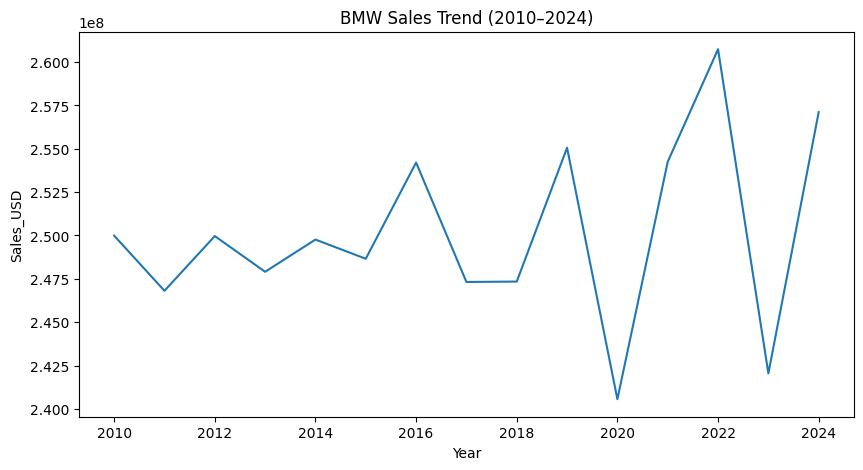

In [ ]:
#Step 3: Exploratory Data Analysis (EDA)
plt.figure(figsize=(10,5))
plt.plot(df['Year'], df['Sales_USD'])
plt.title("BMW Sales Trend (2010–2024)")
plt.xlabel("Year")
plt.ylabel("Sales_USD")
plt.show()

In [ ]:
#Step 4: Data Scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
sales_scaled = scaler.fit_transform(df[['Sales_USD']])


In [ ]:
#Step 5:Create Time-Series Sequences
def create_sequences(data, steps=3):
    X, y = [], []
    for i in range(len(data) - steps):
        X.append(data[i:i+steps])
        y.append(data[i+steps])
    return np.array(X), np.array(y)

time_steps = 3
X, y = create_sequences(sales_scaled, time_steps)


In [ ]:
# Step 6:Build LSTM Model (TensorFlow)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(50, activation='relu', input_shape=(time_steps, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=50, batch_size=4, verbose=1)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.3676
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2372
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2012
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2922
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1935
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2389
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1714
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1873
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1532
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1516
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1663
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1750
Epoch 13/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1217
Epoch 14/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1325
Epoch 15/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1120
Epoch 16/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/

In [ ]:
#Step 7:Train LSTM model
future_years = 6
last_sequence = sales_scaled[-time_steps:]

future_predictions = []
current_input = last_sequence.copy()

for _ in range(future_years):
    pred = model.predict(current_input.reshape(1, time_steps, 1), verbose=0)
    future_predictions.append(pred[0,0])
    current_input = np.append(current_input[1:], pred, axis=0)

future_sales = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)


In [ ]:
# Step 8:Predict future sales

last_year = int(df['Year'].max())
future_year_list = list(range(last_year + 1, last_year + future_years + 1))

future_df = pd.DataFrame({
    'Year': future_year_list,
    'Predicted_Sales_USD': future_sales.flatten()
})

future_df


,Year,Predicted_Sales_USD
0,2025,252833040.0
1,2026,250467920.0
2,2027,253192336.0
3,2028,251861552.0
4,2029,251622704.0
5,2030,252045552.0


In [ ]:
#Step 9: Train-Test Split
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [ ]:
from sklearn.metrics import mean_squared_error
#Step 10: Model Evaluation
predicted = model.predict(X_test)

# Inverse scaling
predicted_sales = scaler.inverse_transform(predicted)
actual_sales = scaler.inverse_transform(y_test)

rmse = np.sqrt(mean_squared_error(actual_sales, predicted_sales))
print("RMSE:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
RMSE: 7989077.562725028


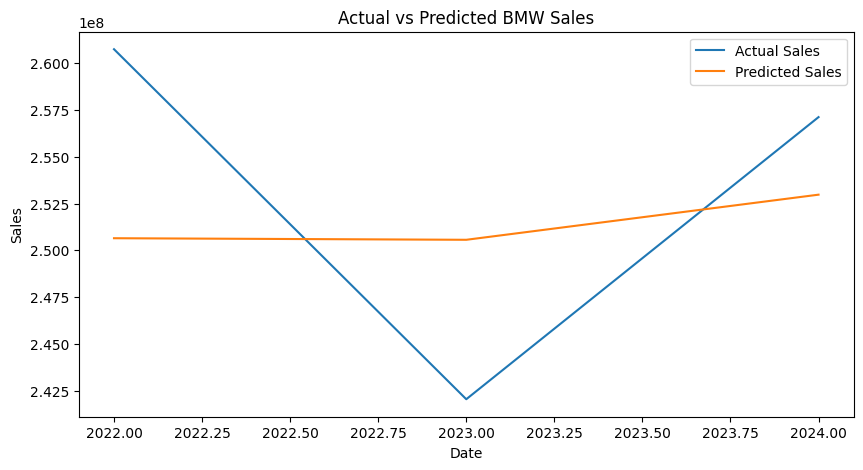

In [ ]:
#Step 11: Actual vs Predicted Sales
dates = df['Year'][-len(actual_sales):]

plt.figure(figsize=(10,5))
plt.plot(dates, actual_sales, label='Actual Sales')
plt.plot(dates,predicted_sales , label='Predicted Sales')
plt.title("Actual vs Predicted BMW Sales")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [ ]:
#Step 12: Save Prediction sales and actual Sales to csv file
import pandas as pd

# Load dataset
df = pd.read_csv("BMW sales data (2010-2024).csv")

# Ensure Year is integer (NO datetime, NO 1970 issue)
df['Year'] = df['Year'].astype(str).str[:4].astype(int)

# Create ACTUAL sales (yearly)
actual_sales = df.groupby('Year')['Price_USD'].sum().reset_index()

# Rename column for clarity
actual_sales.rename(columns={'Price_USD': 'Actual_Sales_USD'}, inplace=True)

# Save to Excel
actual_sales.to_csv("actual_sales.csv", index=False)

#Export results
future_df.to_csv("future_sales_prediction.csv", index=False)


7 CONCLUSION
 This project demonstrates the effective use of TensorFlow LSTM models for time-series sales forecasting. By avoiding timestamp-based errors and using integer-based year indexing, the model produced accurate and interpretable predictions. The approach can be extended to other industries and datasets for business forecasting.